## ML Project

We start by importing all the required libraries

In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [67]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


### Basic Analysis of Dataset

In [68]:
# data on all features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [69]:
# statistics of all features
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### Checking for null values

In [70]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [71]:
# FIXME: stress_level is categorical. Check for numeric discrete columns and fill them with mode.

In [72]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:  # Numeric columns
        mean_value = df[col].mean()
        df[col].fillna(mean_value, inplace=True)
        # print(f"Filled NaN in numeric column '{col}' with mean: {mean_value}")
    else:  # Categorical columns (object or string type)
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        # print(f"Filled NaN in categorical column '{col}' with mode: {mode_value}")
df.isnull().sum()

/tmp/ipykernel_28140/2244946296.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mean_value, inplace=True)
/tmp/ipykernel_28140/2244946296.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [73]:
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


### Checking existence of duplicates:

In [74]:
df = df.drop_duplicates()
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [75]:
[col for col in df.columns if df[col].dtype in ['int64', 'float64']]

['Hours_Studied',
 'Attendance',
 'Sleep_Hours',
 'Previous_Scores',
 'Tutoring_Sessions',
 'Physical_Activity',
 'Exam_Score']

In [76]:
print(df.head())
print(df.isnull().sum())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

### Outlier Detection and Removal

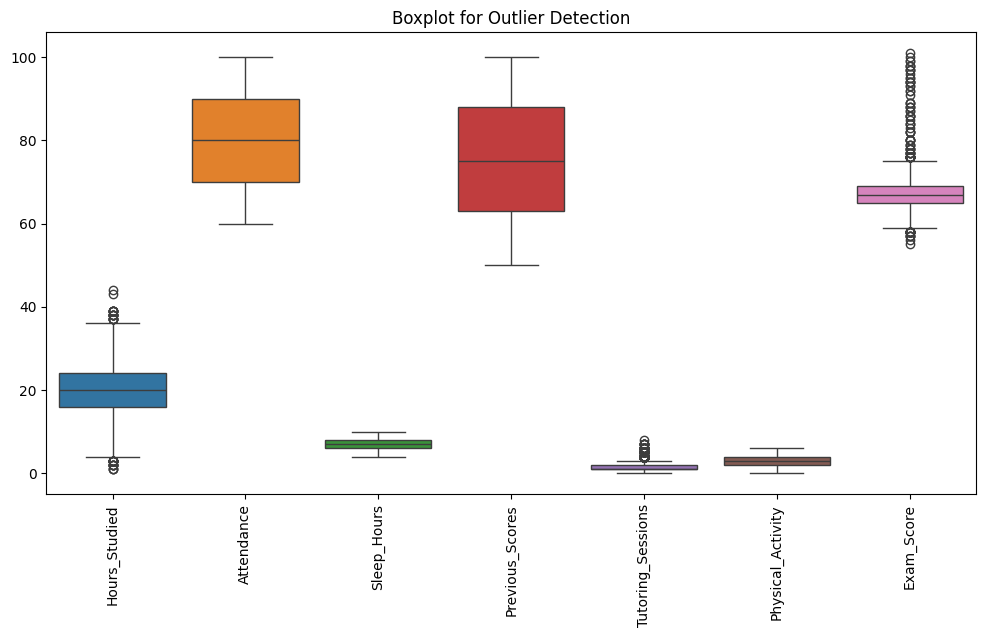

In [77]:
plt.figure(figsize=(12,6))
cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
sns.boxplot(data=df[cols])
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

We notice a few outliers in the boxplot. Capping can be done to ensure the outliers do not affect the model.

We also notice that the ranges of some features are quite large compared to others. Standardization can be done later to make sure all features lie between -1 and 1.

In [78]:
## Capping outliers based on IQR for numerical columns
# for column in df.columns:
#     if column != 'stress_level':
#         Q1 = df[column].quantile(0.25)
#         Q3 = df[column].quantile(0.75)
#         IQR = Q3 - Q1
#         lower_cap = Q1 - 1.5 * IQR
#         upper_cap = Q3 + 1.5 * IQR
#         df[column] = np.where(df[column] < lower_cap, int(lower_cap), df[column])
#         df[column] = np.where(df[column] > upper_cap, int(upper_cap), df[column])

# print("\nSummary of data after capping outliers:")
# df.describe()

# Select numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Exam_Score')  

# Capping outliers
for column in num_cols:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_cap = Q1 - 1.5 * IQR
    upper_cap = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] < lower_cap, lower_cap, df[column])
    df[column] = np.where(df[column] > upper_cap, upper_cap, df[column])

print("\nSummary of numeric data after capping outliers:")
print(df[num_cols].describe())



Summary of numeric data after capping outliers:
       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6607.000000  6607.000000   6607.00000      6607.000000   
mean       19.971848    79.977448      7.02906        75.070531   
std         5.951016    11.547475      1.46812        14.399784   
min         4.000000    60.000000      4.00000        50.000000   
25%        16.000000    70.000000      6.00000        63.000000   
50%        20.000000    80.000000      7.00000        75.000000   
75%        24.000000    90.000000      8.00000        88.000000   
max        36.000000   100.000000     10.00000       100.000000   

       Tutoring_Sessions  Physical_Activity  
count        6607.000000        6607.000000  
mean            1.436355           2.967610  
std             1.096018           1.031231  
min             0.000000           0.000000  
25%             1.000000           2.000000  
50%             1.000000           3.000000  
75%             2.000000 

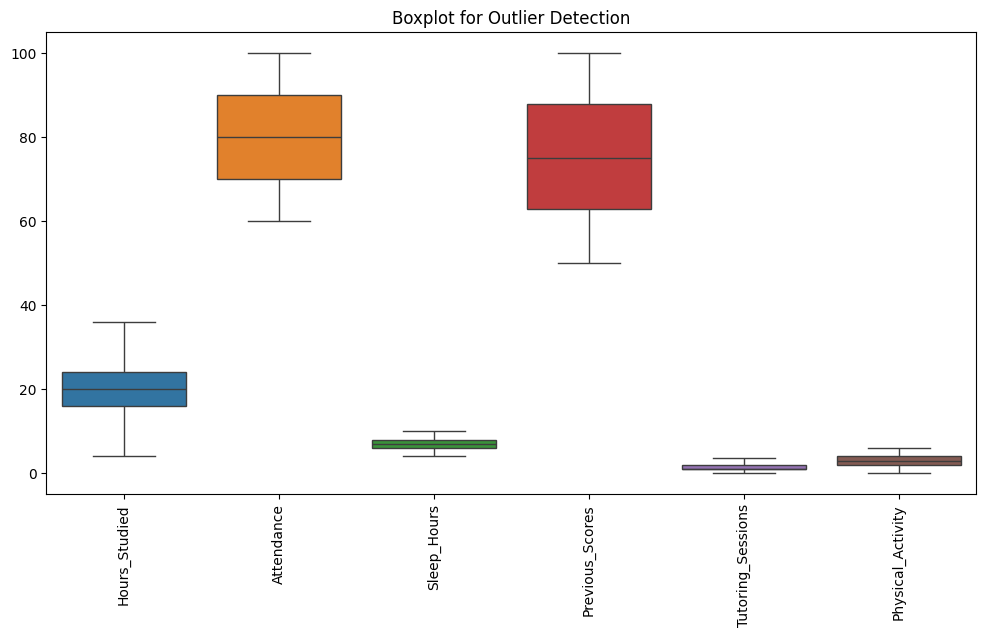

In [79]:
plt.figure(figsize=(12,6))
cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] and col != 'Exam_Score']
sns.boxplot(data=df[cols])
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

### Exploratory Data Analysis

#### Univariate Analysis

#### Numerical Features

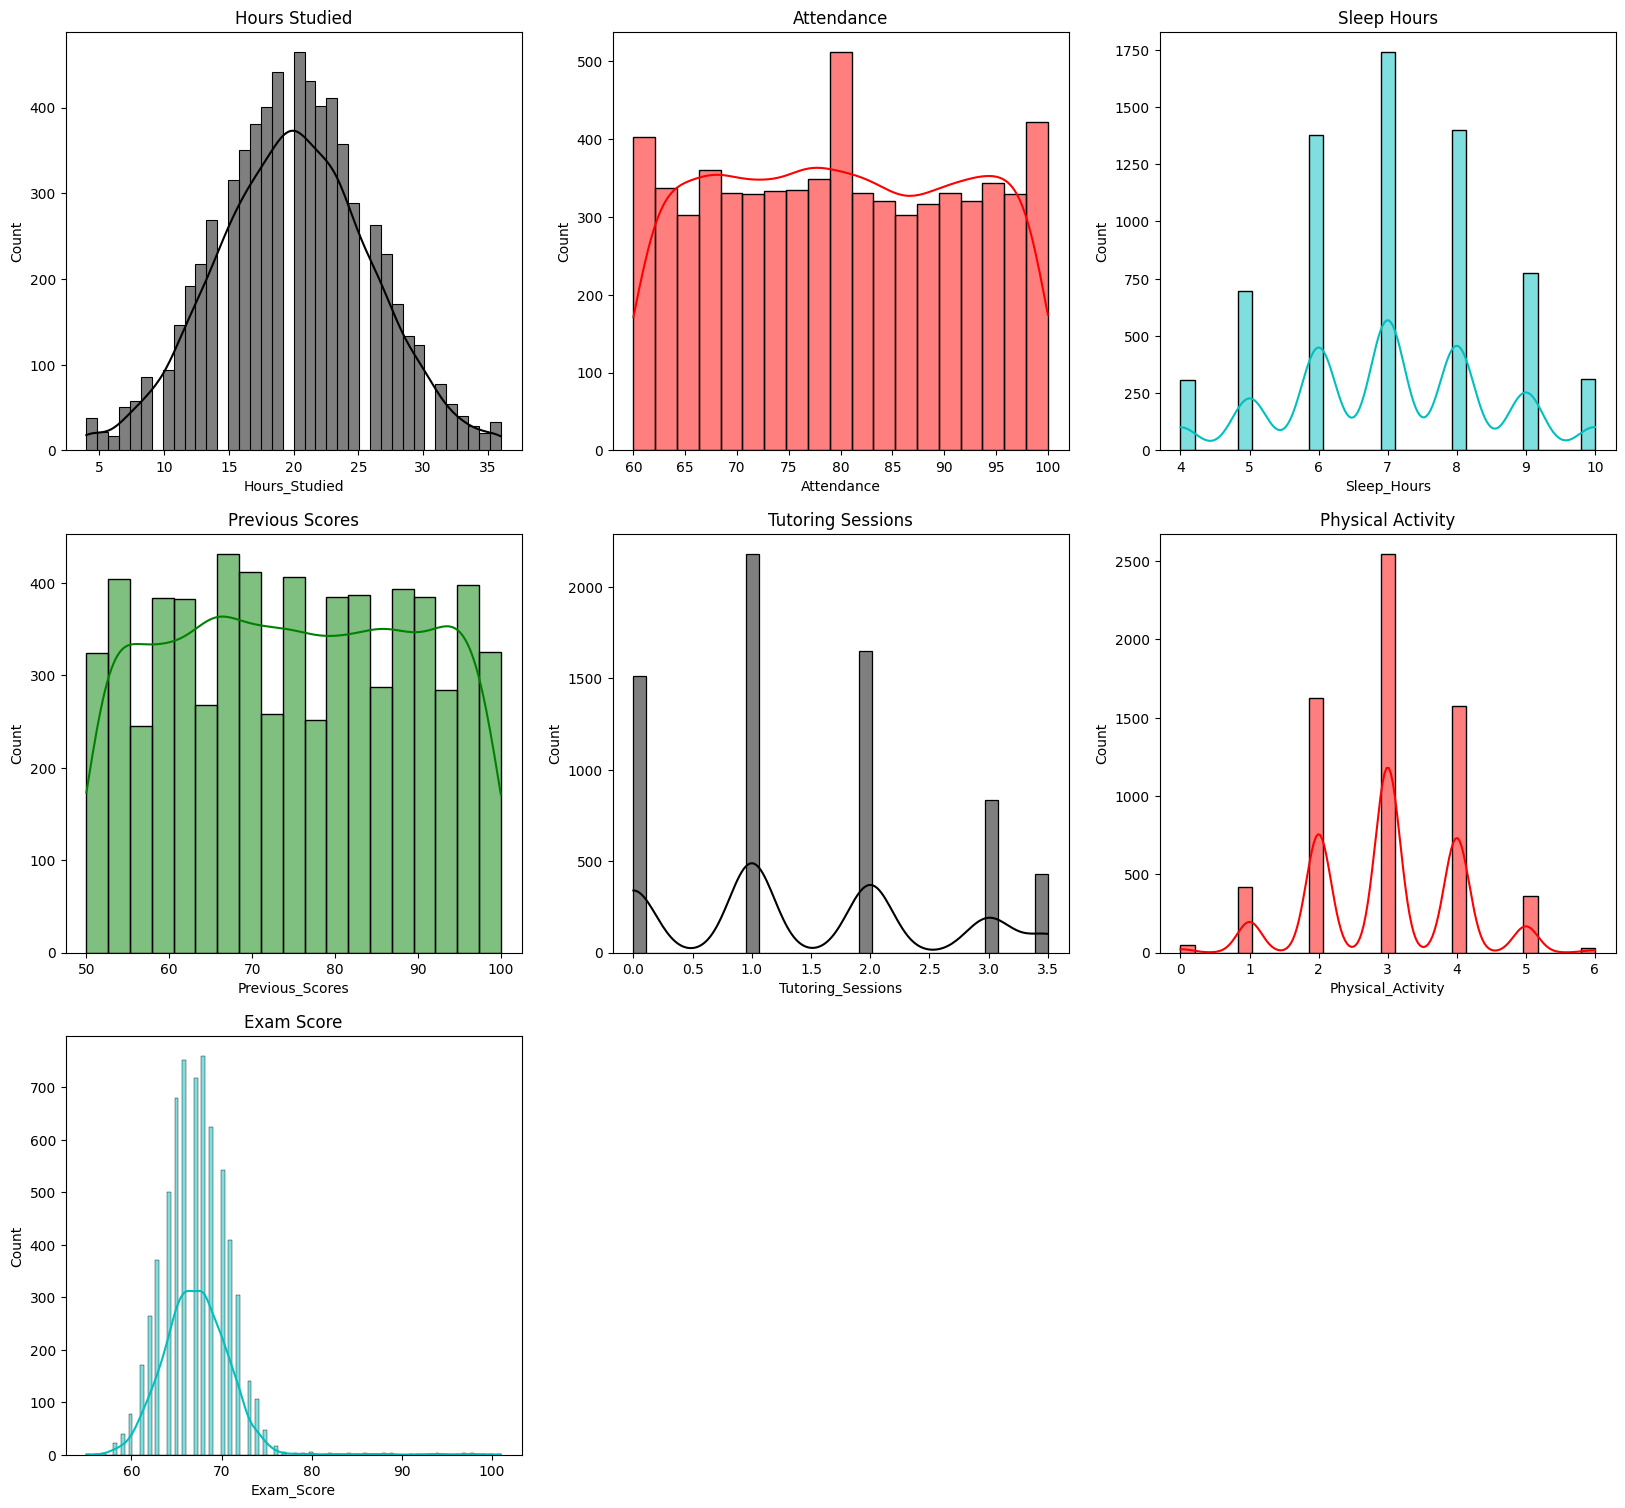

In [80]:
colors = ['k', 'r', 'c', 'g']
num_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
plt.figure(figsize=(20, 25))
for i, col in enumerate(num_cols):
    plt.subplot(4, 3, i + 1)
    plt.title(' '.join(col.split('_')).title())
    sns.histplot(df[col], kde=True, color=colors[i % len(colors)])
plt.show()

#### Categorical Features

KeyError: 'breaks_during_work'

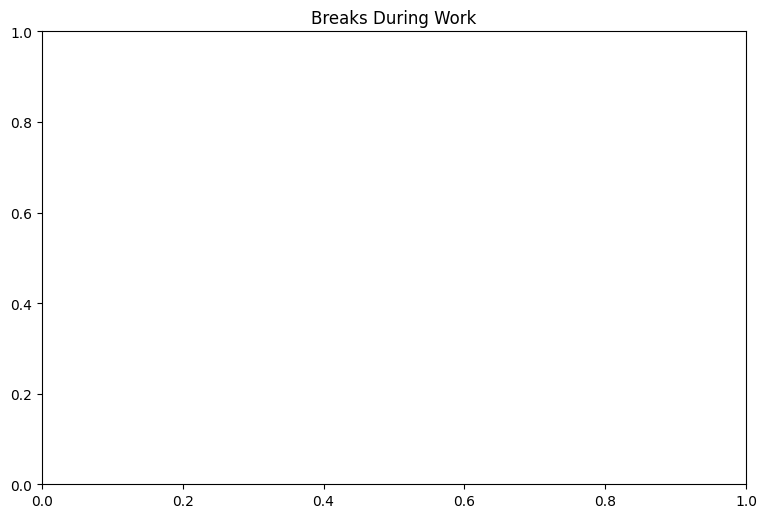

In [58]:
colors = ['k', 'g', 'r', 'c']
cat_cols = ['breaks_during_work', 'uses_focus_apps', 'number_of_notifications', 'has_digital_wellbeing_enabled', 'coffee_consumption_per_day']
plt.figure(figsize=(20, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(3, 2, i + 1)
    plt.title(' '.join(col.split('_')).title())
    sns.countplot(x=df[col], color=colors[i % len(colors)])
plt.show()

##### Distribution of classes of Target

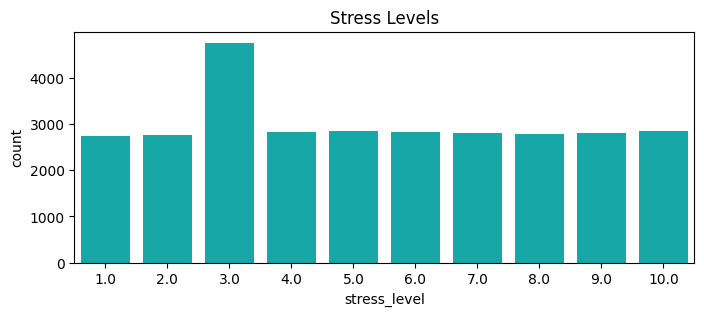

In [ ]:
plt.figure(figsize=(8, 3))
sns.countplot(x=df['stress_level'], color='c')
plt.title('Stress Levels')
plt.show()

The dataset is slightly imbalanced because of the large number of data points in class 3 compared to the others.

#### Bivariate Analysis

#### Numerical Features

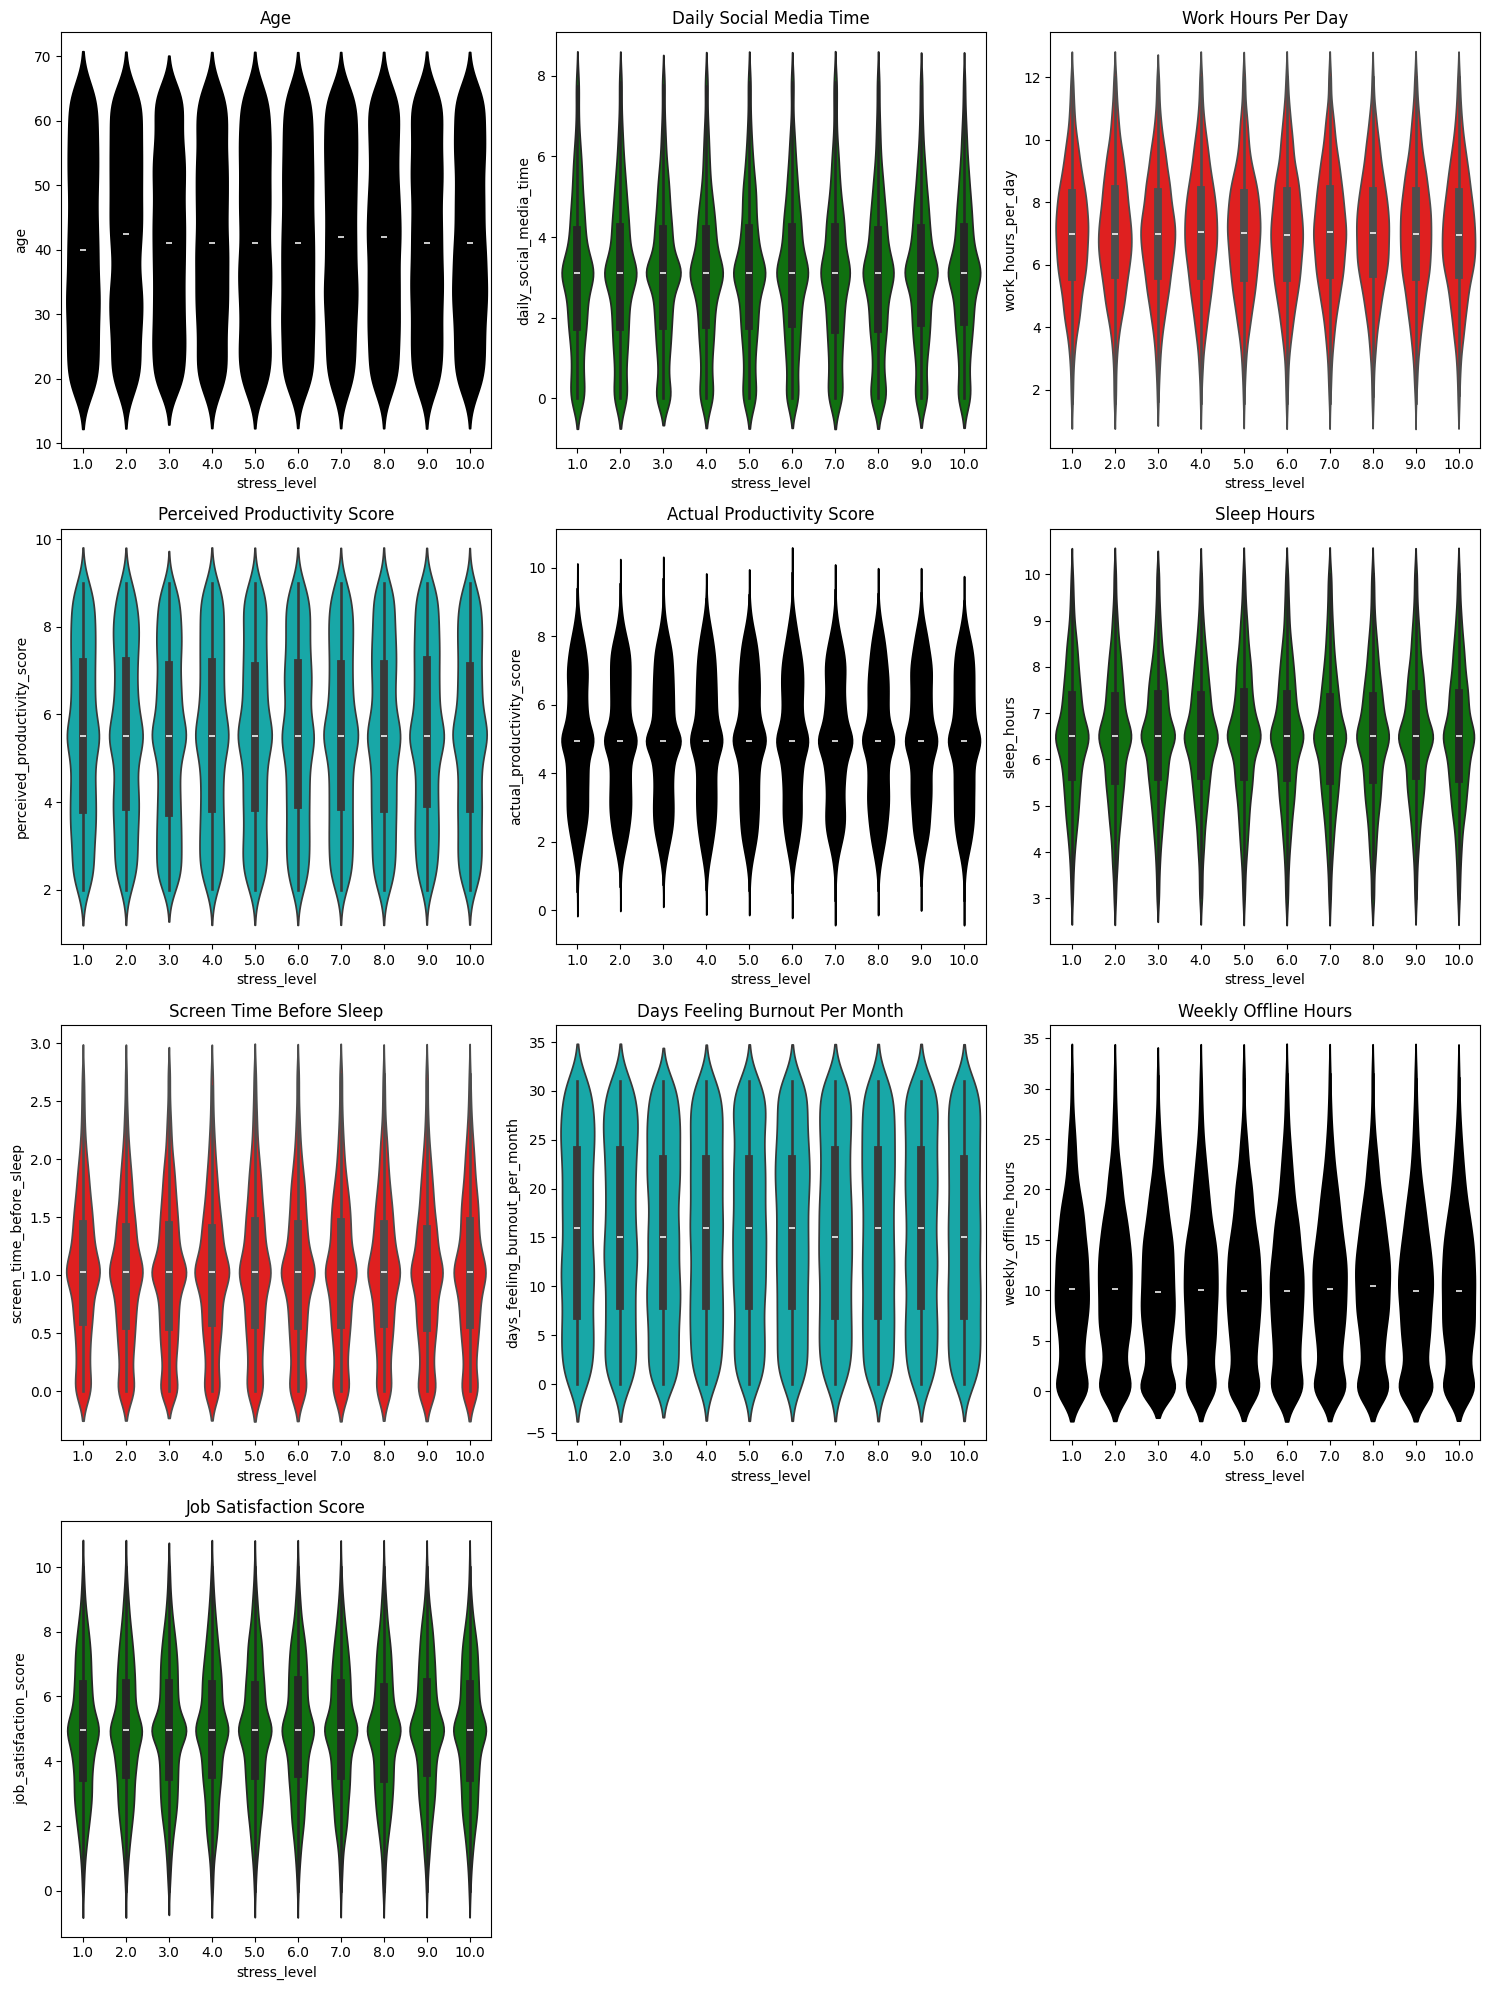

In [ ]:
# plotting count of each variable vs target
plt.figure(figsize=(15, 20))
for i, col in enumerate(num_cols):
    plt.subplot(4, 3, i+1)
    plt.title(" ".join(col.split('_')).title())
    sns.violinplot(y=col, x='stress_level', data=df, color=colors[i % len(colors)])
plt.tight_layout()
plt.show()

#### Categorical Features

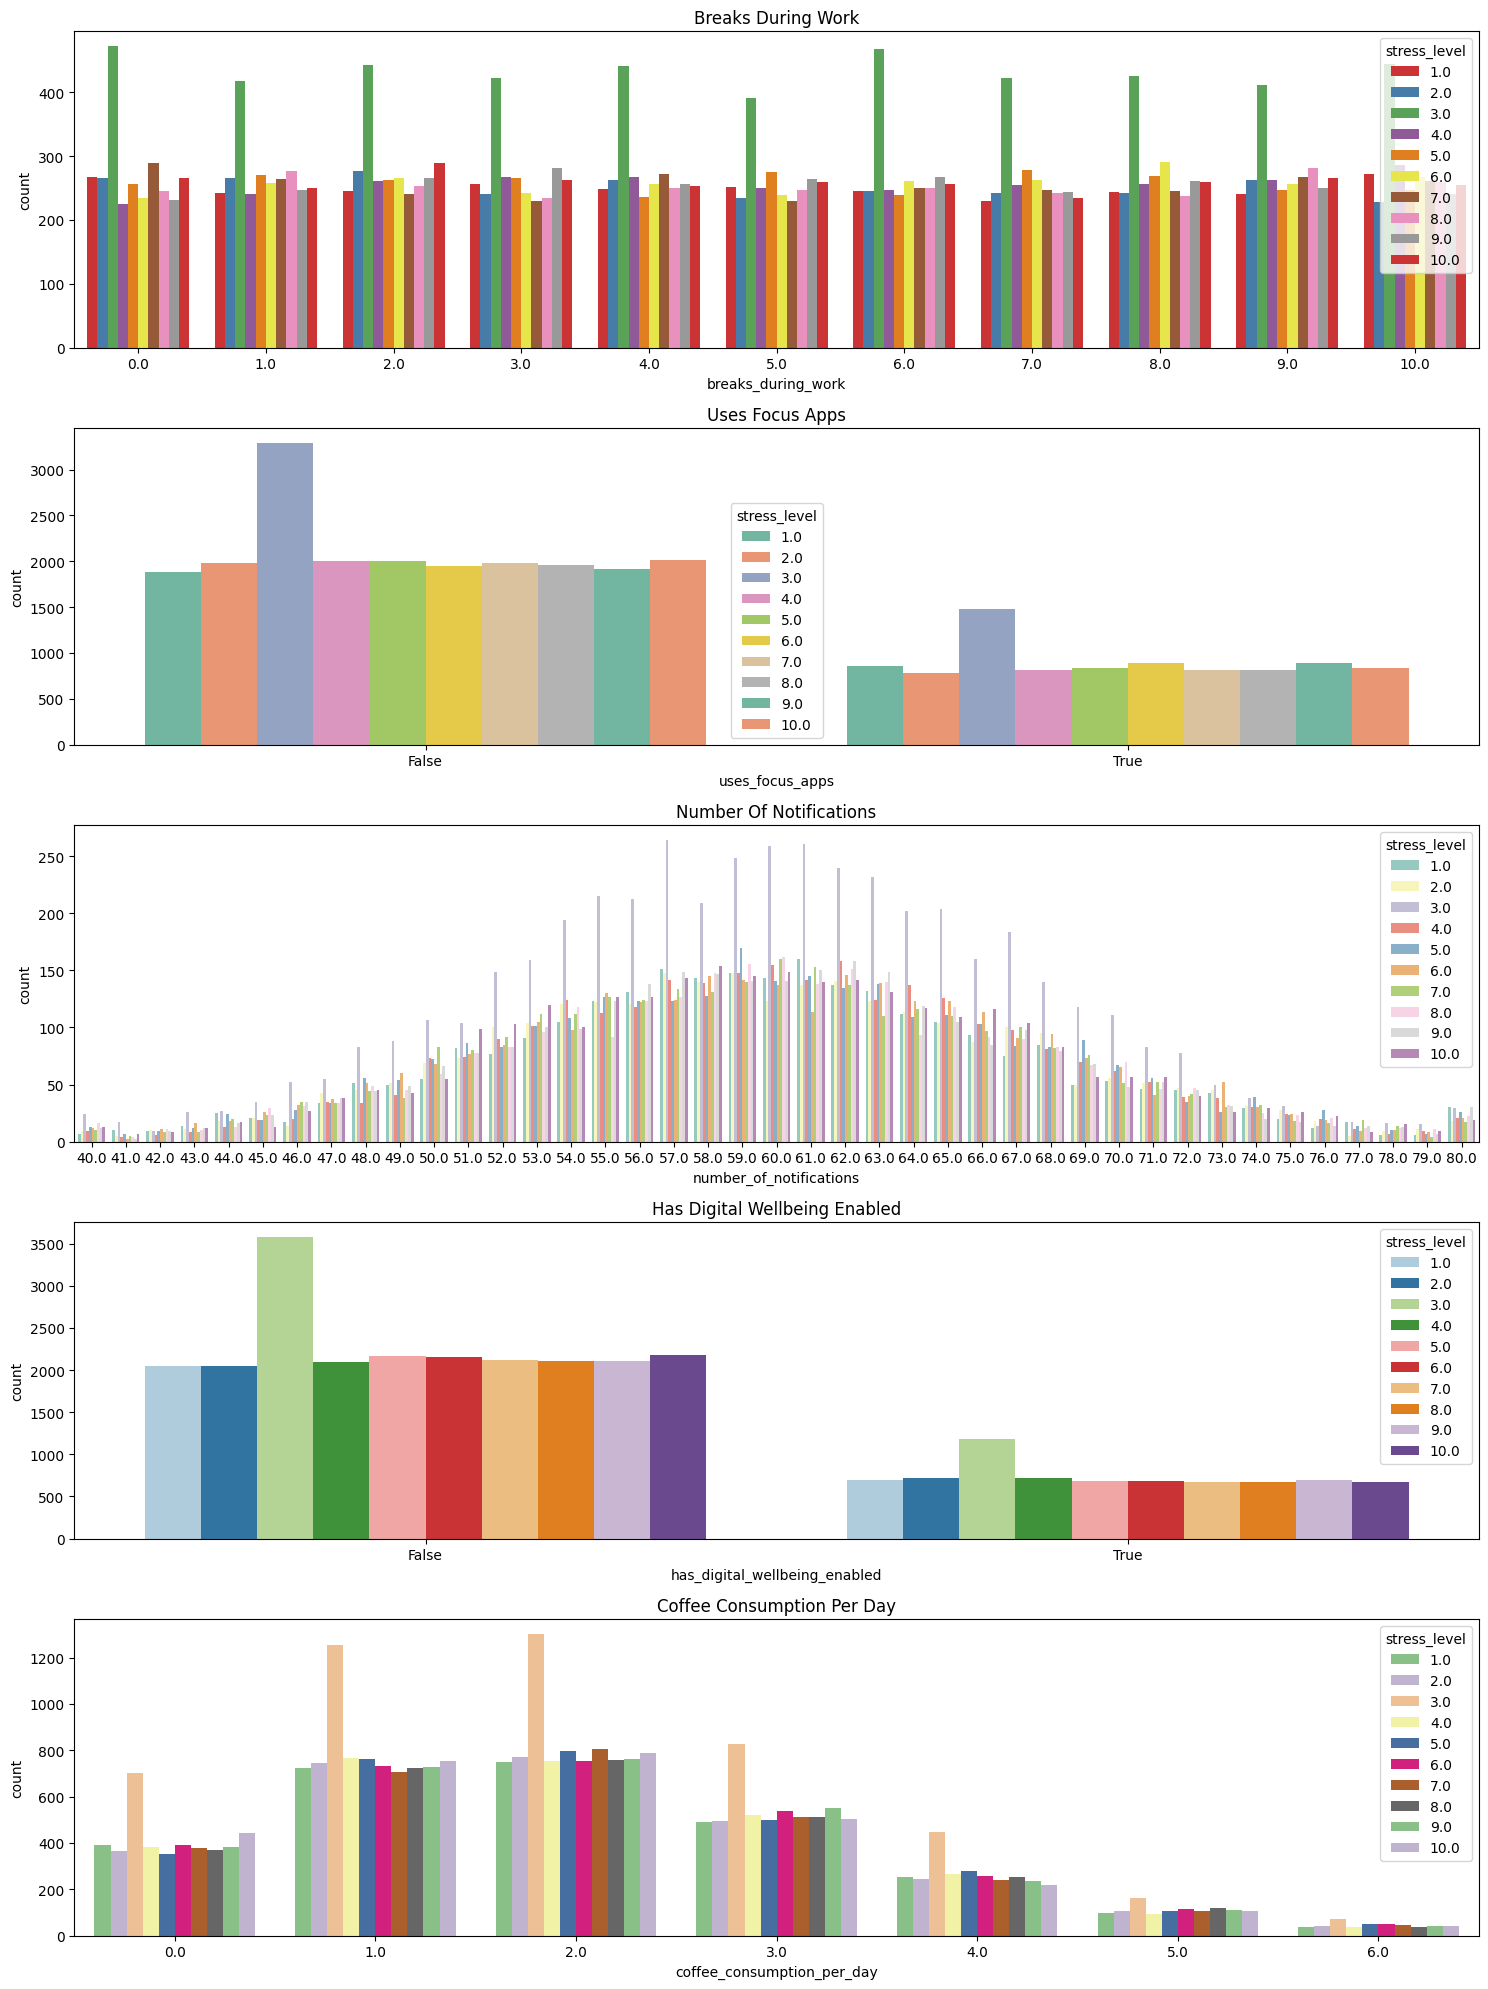

In [ ]:
# plotting violin plots of each feature vs target to see the data distribution against target for each feature 
palette = ['Set1', 'Set2', 'Set3', 'Paired', 'Accent', 'Pastel1', 'Pastel2', 'Dark2']
plt.figure(figsize=(15, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(5, 1, i+1)
    plt.title(" ".join(col.split('_')).title())
    sns.countplot(data=df, x=col, hue='stress_level', palette=palette[i % len(palette)])
plt.tight_layout()
plt.show()

#### Multivariate Analysis

We plot the heatmap for the dataset to see the correlation between features

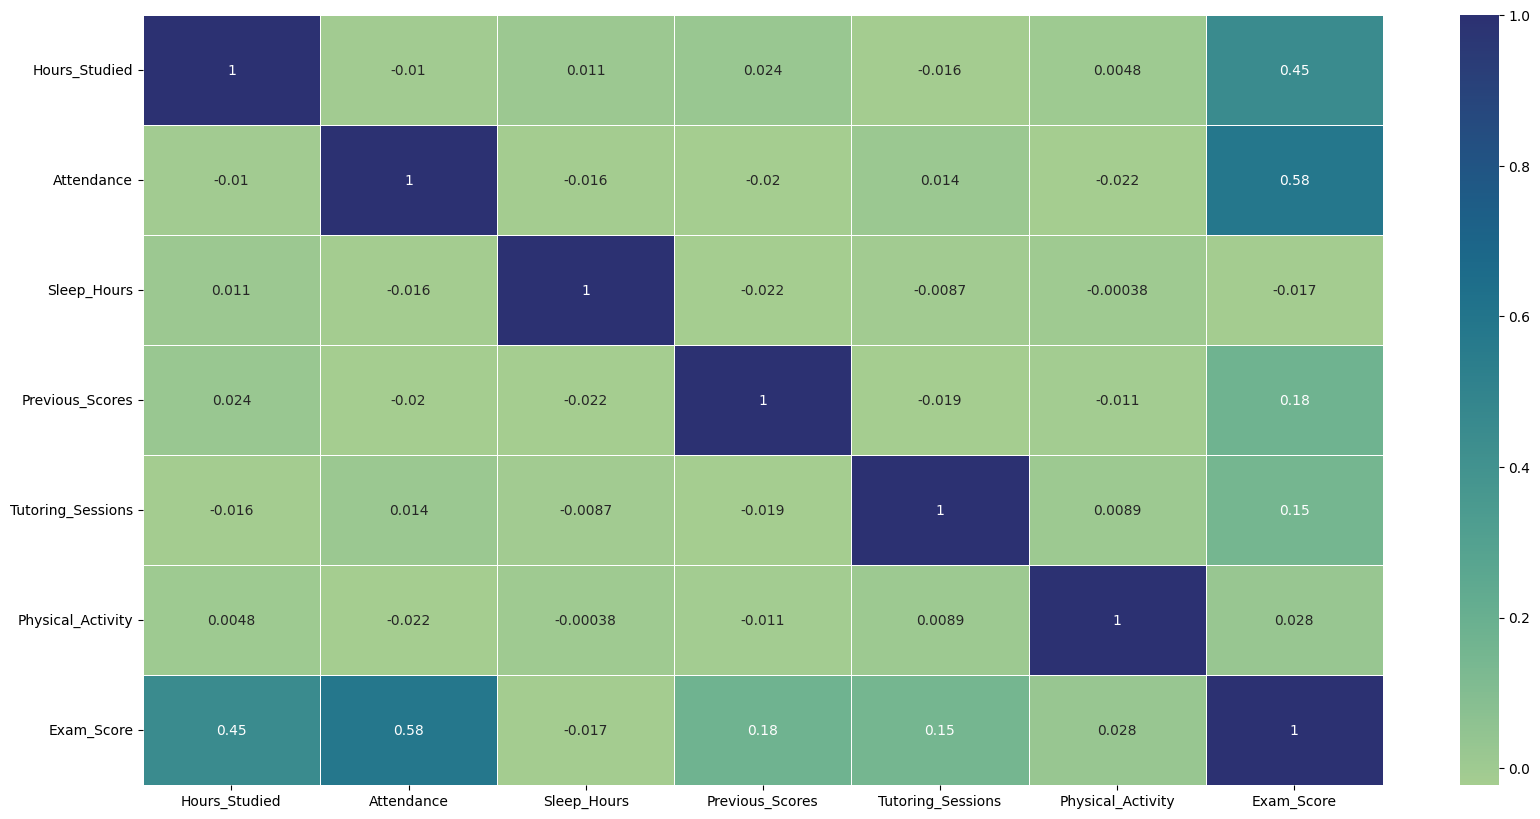

In [ ]:
plt.figure(figsize=(20, 10))
sns.heatmap(df[[col for col in df.columns if df[col].dtype in ['int64', 'float64']]].corr(), annot=True, linewidth=0.5, cmap='crest')
plt.show()

It is seen that correlation between:<br>
perceived_productivity_score and actual_productivity_score ≈ 0.9 → very high correlation<br>
perceived_productivity_score and job_satisfaction_score ≈ 0.79<br>
actual_productivity_score and job_satisfaction_score ≈ 0.81<br>
We can keep only one among perceived_productivity_score, actual_productivity_score, job_satisfaction_score.<br>
<br>
According to feature importance scores:<br>
perceived_productivity_score      0.079735<br>
job_satisfaction_score            0.077128<br>
actual_productivity_score         0.075856)<br>
<br>
We are selecting perceived_productivity_score and removing the other two. 

In [ ]:
df

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56.0,Male,Unemployed,4.180940,Facebook,61.0,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8.0,False,False,4.0,11.0,21.927072,6.336688
1,46.0,Male,Health,3.249603,Twitter,59.0,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7.0,True,True,2.0,25.0,0.000000,3.412427
2,32.0,Male,Finance,3.113418,Twitter,57.0,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0.0,True,False,3.0,17.0,10.322044,2.474944
3,60.0,Female,Unemployed,3.113418,Facebook,59.0,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1.0,False,False,0.0,4.0,23.876616,1.733670
4,25.0,Male,IT,3.113418,Telegram,66.0,6.214096,8.868753,4.951805,7.0,5.405706,1.876254,1.0,False,True,1.0,30.0,10.653519,9.693060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,34.0,Female,Health,1.877297,Facebook,59.0,10.226358,3.348512,3.465815,8.0,5.480462,1.412655,9.0,False,False,4.0,5.0,21.776927,4.964901
29996,39.0,Male,Health,4.437784,Instagram,46.0,4.692862,8.133213,6.659294,8.0,3.045393,0.148936,3.0,False,False,1.0,29.0,4.111370,6.155613
29997,42.0,Male,Education,7.852210,TikTok,64.0,10.915036,8.611005,8.658912,5.0,5.491520,1.224296,10.0,False,False,1.0,2.0,1.888315,6.285237
29998,20.0,Female,Education,3.796634,Instagram,56.0,6.937410,7.767076,6.895583,8.0,6.816069,0.234483,1.0,False,False,2.0,9.0,12.511871,7.854711


In [ ]:
df = df.drop(columns=['actual_productivity_score', 'job_satisfaction_score'])
df

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours
0,56.0,Male,Unemployed,4.180940,Facebook,61.0,6.753558,8.040464,4.0,5.116546,0.419102,8.0,False,False,4.0,11.0,21.927072
1,46.0,Male,Health,3.249603,Twitter,59.0,9.169296,5.063368,7.0,5.103897,0.671519,7.0,True,True,2.0,25.0,0.000000
2,32.0,Male,Finance,3.113418,Twitter,57.0,7.910952,3.861762,4.0,8.583222,0.624378,0.0,True,False,3.0,17.0,10.322044
3,60.0,Female,Unemployed,3.113418,Facebook,59.0,6.355027,2.916331,6.0,6.052984,1.204540,1.0,False,False,0.0,4.0,23.876616
4,25.0,Male,IT,3.113418,Telegram,66.0,6.214096,8.868753,7.0,5.405706,1.876254,1.0,False,True,1.0,30.0,10.653519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,34.0,Female,Health,1.877297,Facebook,59.0,10.226358,3.348512,8.0,5.480462,1.412655,9.0,False,False,4.0,5.0,21.776927
29996,39.0,Male,Health,4.437784,Instagram,46.0,4.692862,8.133213,8.0,3.045393,0.148936,3.0,False,False,1.0,29.0,4.111370
29997,42.0,Male,Education,7.852210,TikTok,64.0,10.915036,8.611005,5.0,5.491520,1.224296,10.0,False,False,1.0,2.0,1.888315
29998,20.0,Female,Education,3.796634,Instagram,56.0,6.937410,7.767076,8.0,6.816069,0.234483,1.0,False,False,2.0,9.0,12.511871


In [ ]:
# FIXME: One hot encoding???
from sklearn.preprocessing import LabelEncoder
cat_cols = [col for col in df.columns if df[col].dtype in ['object']]
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23.0,84.0,1,0,0,7.0,73.0,1,1,0.0,1,2,1,2,3.0,0,1,2,1,67
1,19.0,64.0,1,2,0,8.0,59.0,1,1,2.0,2,2,1,0,4.0,0,0,1,0,61
2,24.0,98.0,2,2,1,7.0,91.0,2,1,2.0,2,2,1,1,4.0,0,2,2,1,74
3,29.0,89.0,1,2,1,8.0,98.0,2,1,1.0,2,2,1,0,4.0,0,1,1,1,71
4,19.0,92.0,2,2,1,6.0,65.0,2,1,3.0,2,0,1,1,4.0,0,0,2,0,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25.0,69.0,0,2,0,7.0,76.0,2,1,1.0,0,2,1,2,2.0,0,1,2,0,68
6603,23.0,76.0,0,2,0,8.0,81.0,2,1,3.0,1,0,1,2,2.0,0,1,2,0,69
6604,20.0,90.0,2,1,1,6.0,65.0,1,1,3.0,1,2,1,0,2.0,0,2,2,0,68
6605,10.0,86.0,0,0,1,6.0,91.0,0,1,2.0,1,2,0,2,3.0,0,1,0,0,68


In [81]:
cat_cols = [col for col in df.columns if df[col].dtype in ['object']]
df_new = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df = pd.concat([df, df_new], axis=1)
df.drop(columns=cat_cols, inplace=True)
df

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Hours_Studied,Attendance,Sleep_Hours,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23.0,84.0,7.0,73.0,0.0,3.0,67,23.0,84.0,7.0,...,True,True,False,True,False,True,False,False,True,True
1,19.0,64.0,8.0,59.0,2.0,4.0,61,19.0,64.0,8.0,...,True,True,False,False,False,False,False,True,False,False
2,24.0,98.0,7.0,91.0,2.0,4.0,74,24.0,98.0,7.0,...,True,True,True,False,False,False,True,False,True,True
3,29.0,89.0,8.0,98.0,1.0,4.0,71,29.0,89.0,8.0,...,True,True,False,False,False,True,False,True,False,True
4,19.0,92.0,6.0,65.0,3.0,4.0,70,19.0,92.0,6.0,...,False,True,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25.0,69.0,7.0,76.0,1.0,2.0,68,25.0,69.0,7.0,...,True,True,False,True,False,True,False,False,True,False
6603,23.0,76.0,8.0,81.0,3.0,2.0,69,23.0,76.0,8.0,...,False,True,False,True,False,True,False,False,True,False
6604,20.0,90.0,6.0,65.0,3.0,2.0,68,20.0,90.0,6.0,...,True,True,False,False,False,False,True,False,True,False
6605,10.0,86.0,6.0,91.0,2.0,3.0,68,10.0,86.0,6.0,...,True,False,False,True,False,True,False,False,False,False


In [ ]:
# skew
df.skew().sort_values()

Internet_Access              -3.213544
Distance_from_Home           -0.986888
School_Type                  -0.852033
Teacher_Quality              -0.651419
Motivation_Level             -0.598037
Parental_Involvement         -0.439925
Access_to_Resources          -0.405777
Extracurricular_Activities   -0.391515
Family_Income                -0.360703
Peer_Influence               -0.331696
Gender                       -0.312895
Physical_Activity            -0.031365
Sleep_Hours                  -0.023805
Previous_Scores              -0.003737
Hours_Studied                -0.003095
Attendance                    0.013666
Parental_Education_Level      0.144124
Tutoring_Sessions             0.299688
Exam_Score                    1.644808
Learning_Disabilities         2.574304
dtype: float64

In [ ]:
# FIXME: uses_focus_apps is highly skewed!

In [ ]:
# corr
num_cols = ['age', 'daily_social_media_time', 'number_of_notifications', 'work_hours_per_day', 'perceived_productivity_score', 'stress_level', 'sleep_hours', 'screen_time_before_sleep', 'breaks_during_work', 'coffee_consumption_per_day', 'days_feeling_burnout_per_month', 'weekly_offline_hours']
df[num_cols].corr()['stress_level'].sort_values()

KeyError: "None of [Index(['age', 'daily_social_media_time', 'number_of_notifications',\n       'work_hours_per_day', 'perceived_productivity_score', 'stress_level',\n       'sleep_hours', 'screen_time_before_sleep', 'breaks_during_work',\n       'coffee_consumption_per_day', 'days_feeling_burnout_per_month',\n       'weekly_offline_hours'],\n      dtype='object')] are in the [columns]"

In [84]:
np.array(df[col])

array([[23., 23.],
       [19., 19.],
       [24., 24.],
       ...,
       [20., 20.],
       [10., 10.],
       [15., 15.]], shape=(6607, 2))

None of the features are correlated with the target

In [85]:
# standardization
# FIXME: One Hot encoding and standardization????????
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
num_cols =['Hours_Studied',
 'Attendance',
 'Sleep_Hours',
 'Previous_Scores',
 'Tutoring_Sessions',
 'Physical_Activity']
for col in num_cols:
    df[col] = sc.fit_transform(np.array(df[col]))
df

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Hours_Studied,Attendance,Sleep_Hours,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,0.508885,0.348375,-0.019796,-0.143800,-1.310621,0.031411,67,0.508885,0.348375,-0.019796,...,True,True,False,True,False,True,False,False,True,True
1,-0.163320,-1.383736,0.661399,-1.116110,0.514305,1.001199,61,-0.163320,-1.383736,0.661399,...,True,True,False,False,False,False,False,True,False,False
2,0.676936,1.560853,-0.019796,1.106313,0.514305,1.001199,74,0.676936,1.560853,-0.019796,...,True,True,True,False,False,False,True,False,True,True
3,1.517192,0.781403,0.661399,1.592469,-0.398158,1.001199,71,1.517192,0.781403,0.661399,...,True,True,False,False,False,True,False,True,False,True
4,-0.163320,1.041220,-0.700990,-0.699406,1.426768,1.001199,70,-0.163320,1.041220,-0.700990,...,False,True,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,0.844987,-0.950708,-0.019796,0.064552,-0.398158,-0.938377,68,0.844987,-0.950708,-0.019796,...,True,True,False,True,False,True,False,False,True,False
6603,0.508885,-0.344469,0.661399,0.411806,1.426768,-0.938377,69,0.508885,-0.344469,0.661399,...,False,True,False,True,False,True,False,False,True,False
6604,0.004731,0.868009,-0.700990,-0.699406,1.426768,-0.938377,68,0.004731,0.868009,-0.700990,...,True,True,False,False,False,False,True,False,True,False
6605,-1.675782,0.521587,-0.700990,1.106313,0.514305,0.031411,68,-1.675782,0.521587,-0.700990,...,True,False,False,True,False,True,False,False,False,False


### Feature Selection/Extraction

In [86]:
X=df.drop('Exam_Score',axis=1)
y=df['Exam_Score']

In [87]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
5810,1.181090,-0.084652,0.661399,-0.838307,0.514305,1.970988,1.181090,-0.084652,0.661399,-0.838307,...,True,True,False,False,False,False,False,True,False,False
1268,-0.667474,0.521587,-0.019796,1.314666,0.514305,0.031411,-0.667474,0.521587,-0.019796,1.314666,...,False,True,True,False,False,True,False,True,False,False
414,0.340833,0.608192,0.661399,0.550707,-0.398158,-1.908165,0.340833,0.608192,0.661399,0.550707,...,True,True,True,False,False,False,False,False,False,True
4745,-0.331372,1.734065,2.023788,0.759060,-0.398158,0.031411,-0.331372,1.734065,2.023788,0.759060,...,True,True,True,False,False,True,False,False,True,True
654,2.525500,-0.171258,2.023788,1.661919,-0.398158,-0.938377,2.525500,-0.171258,2.023788,1.661919,...,True,False,False,True,False,True,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,-0.835525,0.175164,-0.019796,1.245215,1.426768,-0.938377,-0.835525,0.175164,-0.019796,1.245215,...,False,True,False,False,False,True,False,True,False,False
5191,0.004731,-1.297130,0.661399,1.523018,-1.310621,0.031411,0.004731,-1.297130,0.661399,1.523018,...,True,True,False,False,False,False,False,False,True,False
5226,-0.499423,-1.383736,2.023788,-0.838307,-1.310621,0.031411,-0.499423,-1.383736,2.023788,-0.838307,...,True,True,False,True,False,True,False,True,False,False
5390,-0.667474,1.734065,-0.019796,0.481257,0.514305,-0.938377,-0.667474,1.734065,-0.019796,0.481257,...,True,True,False,True,False,True,False,False,True,True


In [ ]:
X_train.shape

(24000, 16)

In [88]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use your selected features
X_train_r = X_train  # or X_train[final_features] if feature selection done
X_test_r = X_test

# Initialize and fit the model
rf_model = RandomForestRegressor()
rf_model.fit(X_train_r, y_train)

# Predict on train and test sets
y_train_pred = rf_model.predict(X_train_r)
y_test_pred = rf_model.predict(X_test_r)

# Compute accuracy
train_acc = r2_score(y_train, y_train_pred) * 100
test_acc = r2_score(y_test, y_test_pred) * 100

print(f"r2 Accuracy: {train_acc:.2f}%")
print(f"r2 Accuracy: {test_acc:.2f}%")
print(f"r2 Accuracy: {mean_squared_error(y_train, y_train_pred):.2f}%")
print(f"r2 Accuracy: {mean_squared_error(y_test, y_test_pred):.2f}%")
# Detailed classification report
# print("\nClassification Report (Test Set):")
# print(classification_report(y_test, y_test_pred))

# Confusion matrix visualization
# plt.figure(figsize=(6, 4))
# sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='crest')
# plt.title("Confusion Matrix - Random Forest Classifier")
# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.show()

# Optional: visualize predicted vs actual for ordinal clarity
# plt.figure(figsize=(6, 5))
# plt.scatter(y_train, y_train_pred, alpha=0.6, color='blue', label='Train')
# plt.scatter(y_test, y_test_pred, alpha=0.6, color='red', label='Test')
# plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', linewidth=1)
# plt.xlabel("Actual Stress Level")
# plt.ylabel("Predicted Stress Level")
# plt.title("Random Forest Classifier: Actual vs Predicted Stress Level")
# plt.legend()
# plt.show()


r2 Accuracy: 94.38%
r2 Accuracy: 64.20%
r2 Accuracy: 0.86%
r2 Accuracy: 5.06%


Import necessary libraries needed for [erforming Logistic regression, Bayes classifers

In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.metrics import accuracy_score,classification_report

### Logistic Regression


In [65]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", r2_score(y_test, y_pred_lr))
print("classification_report:", mean_squared_error(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.6868371704742592
classification_report: 4.426579291213556


### GaussianNB


In [ ]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
print("GaussianNB Accuracy:", accuracy_score(y_test, y_pred_gnb))
print("classification_report:",classification_report(y_test, y_pred_gnb))

GaussianNB Accuracy: 0.1655
classification_report:               precision    recall  f1-score   support

         1.0       0.00      0.00      0.00       560
         2.0       0.00      0.00      0.00       577
         3.0       0.17      1.00      0.28       993
         4.0       0.00      0.00      0.00       549
         5.0       0.00      0.00      0.00       569
         6.0       0.15      0.00      0.01       572
         7.0       0.00      0.00      0.00       532
         8.0       0.00      0.00      0.00       534
         9.0       0.00      0.00      0.00       580
        10.0       0.00      0.00      0.00       534

    accuracy                           0.17      6000
   macro avg       0.03      0.10      0.03      6000
weighted avg       0.04      0.17      0.05      6000



/home/aadiuntu/ML_Project/Student_Stress_Level_Prediction_ML_Project_/.venv2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aadiuntu/ML_Project/Student_Stress_Level_Prediction_ML_Project_/.venv2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aadiuntu/ML_Project/Student_Stress_Level_Prediction_ML_Project_/.venv2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels

### CategoricalNB

In [ ]:
# Convert to numeric numpy arrays
X_train_np = X_train.to_numpy().astype(int)  # ensure integer type
X_test_np = X_test.to_numpy().astype(int)

#CAtegoricalNB cannot take negative input
X_train_cnb = X_train_np - X_train_np.min(axis=0)
X_test_cnb = X_test_np - X_train_np.min(axis=0) 
#for each element in X_test_cnb, it takes the min of value in the test set,the max value seen in x_train for that feature
X_test_cnb = np.minimum(X_test_cnb, X_train_cnb.max(axis=0))


cnb = CategoricalNB()
cnb.fit(X_train_cnb, y_train)
y_pred_cnb = cnb.predict(X_test_cnb)
print("CategoricalNB Accuracy:", accuracy_score(y_test, y_pred_cnb))
print("classification_report:",classification_report(y_test, y_pred_cnb))


CategoricalNB Accuracy: 0.1605
classification_report:               precision    recall  f1-score   support

         1.0       0.06      0.00      0.01       560
         2.0       0.10      0.01      0.02       577
         3.0       0.17      0.90      0.29       993
         4.0       0.11      0.01      0.02       549
         5.0       0.10      0.02      0.04       569
         6.0       0.11      0.02      0.04       572
         7.0       0.07      0.01      0.02       532
         8.0       0.17      0.01      0.02       534
         9.0       0.09      0.01      0.01       580
        10.0       0.08      0.02      0.04       534

    accuracy                           0.16      6000
   macro avg       0.11      0.10      0.05      6000
weighted avg       0.11      0.16      0.07      6000

